In [6]:
import numpy as np
import matplotlib.pyplot as plt


## integrado en r con cortes en z

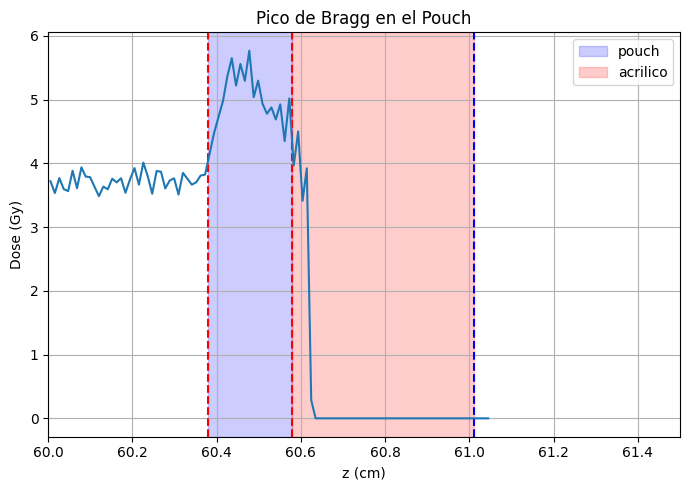

In [7]:
#DOSIS VS Z
archivo = "bragg_pouch_zcilindJesus_M0.out"

tiemporad = 300

z = []
dose = []


with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()


        if len(parts) != 4:
            continue


        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            d = float(parts[2].replace("D", "E"))
            err = float(parts[3].replace("D", "E"))
        except:
            continue


        z.append((z1 + z2) / 2)
        dose.append(d)


plt.figure(figsize=(7,5))

plt.axvline(x=60.58,color='r', linestyle='--')
plt.axvline(x=60.38, color = 'r', linestyle='--')
plt.axvline(x=61.01, color = 'b', linestyle='--')
#plt.axvline(x = 60.23, color = 'g', linestyle='--'  )

plt.axvspan(60.38, 60.58, color='b', alpha=0.2, label='pouch')
plt.axvspan(60.58, 61.01, color='r', alpha=0.2, label='acrilico')
#plt.axvspan(60.23, 60.58, color='g', alpha=0.2, label='gel de ultrasonido')

plt.xlim(60,61.5)
plt.legend()
plt.plot(z, np.array(dose)*tiemporad)
plt.xlabel("z (cm)")
plt.ylabel("Dose (Gy)") # gray por particula simulada (u)
plt.title("Pico de Bragg en el Pouch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# quiero calcular las 2 posiciones en z que le corresponde a Dose = 0.122 Gy
z = np.array(z)
dose = np.array(dose)

dose_corte = 0.0122

zcortes = []

for i in range(len(z)-1):
    if (dose[i] - dose_corte) * (dose[i+1] - dose_corte) <= 0:
        zc = z[i] + (dose_corte - dose[i]) * (z[i+1] - z[i]) / (dose[i+1] - dose[i])
        zcortes.append(zc)

print(f"Para Dose = {dose_corte} Gy, los valores de z son:")

for zc in zcortes:
    print(f"{zc:.4f} cm")

Para Dose = 0.0122 Gy, los valores de z son:
60.0088 cm
60.0217 cm
60.0331 cm
60.0506 cm
60.0666 cm
60.0701 cm
60.1082 cm
60.1458 cm
60.1779 cm
60.1898 cm
60.2417 cm
60.2510 cm
60.2759 cm
60.2826 cm
60.3033 cm
60.3141 cm
60.6016 cm
60.6089 cm
60.6148 cm


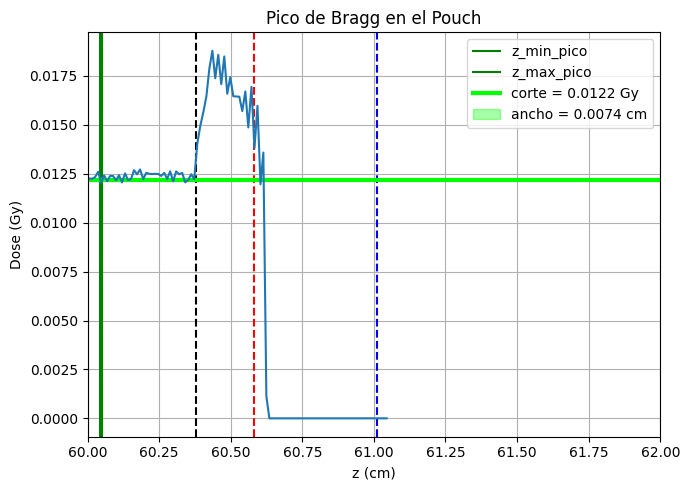

z_min = 60.0445 cm
z_max = 60.0520 cm
ancho = 0.0074 cm
ancho = 0.07 mm


In [5]:
z_pouch_min = 60.38
z_pouch_max = 60.58

z_pico_min = zcortes[0]
z_pico_max = zcortes[1]

ancho_pico = z_pico_max - z_pico_min

plt.figure(figsize=(7,5))

plt.axvline(x=60.38, color='black', linestyle='--')
plt.axvline(x=60.58, color='r', linestyle='--')
plt.axvline(x=61.01, color='b', linestyle='--')
plt.axvline(x=z_pico_min, color='green', label='z_min_pico')
plt.axvline(x=z_pico_max, color='green',  label='z_max_pico')


plt.axhline(dose_corte, color='lime', linewidth=3, label=f'corte = {dose_corte:.4f} Gy')
plt.axvspan(z_pico_min, z_pico_max, color='lime', alpha=0.35, label=f'ancho = {ancho_pico:.4f} cm')

plt.plot(z, dose)

plt.xlim(60, 62)
plt.xlabel("z (cm)")
plt.ylabel("Dose (Gy)")
plt.title("Pico de Bragg en el Pouch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"z_min = {z_pico_min:.4f} cm")
print(f"z_max = {z_pico_max:.4f} cm")
print(f"ancho = {ancho_pico:.4f} cm")
print(f"ancho = {ancho_pico*10:.2f} mm")

## integrado en z con cortes en r